In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Load dataset

In [2]:
DATA_PATH=Path('data/NYC.csv')
df=pd.read_csv(DATA_PATH)
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373


## Basic info about dataset 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


In [4]:
df.head(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [5]:
df.sample(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
67414,id3753140,2,2016-03-15 18:46:00,2016-03-15 18:51:07,1,-73.969040,40.758312,-73.975075,40.752266,N,307
498035,id3821411,2,2016-03-24 12:00:12,2016-03-24 12:11:47,1,-73.981247,40.769058,-73.985100,40.759804,N,695
442396,id2317065,2,2016-01-31 00:04:10,2016-01-31 00:10:41,1,-73.985130,40.750278,-73.972244,40.745644,N,391
387759,id0907361,2,2016-06-24 19:02:56,2016-06-24 19:30:59,1,-74.007111,40.728649,-73.996803,40.718960,N,1683
1311575,id0124883,2,2016-02-02 19:33:16,2016-02-02 19:40:52,1,-73.997162,40.722450,-73.989624,40.736843,N,456


In [6]:
df.shape

(1458644, 11)

In [7]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [8]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [9]:
df.select_dtypes(include='str')

,id,pickup_datetime,dropoff_datetime,store_and_fwd_flag
0,id2875421,2016-03-14 17:24:55,2016-03-14 17:32:30,N
1,id2377394,2016-06-12 00:43:35,2016-06-12 00:54:38,N
2,id3858529,2016-01-19 11:35:24,2016-01-19 12:10:48,N
3,id3504673,2016-04-06 19:32:31,2016-04-06 19:39:40,N
4,id2181028,2016-03-26 13:30:55,2016-03-26 13:38:10,N
...,...,...,...,...
1458639,id2376096,2016-04-08 13:31:04,2016-04-08 13:44:02,N
1458640,id1049543,2016-01-10 07:35:15,2016-01-10 07:46:10,N
1458641,id2304944,2016-04-22 06:57:41,2016-04-22 07:10:25,N
1458642,id2714485,2016-01-05 15:56:26,2016-01-05 16:02:39,N


In [10]:
df.select_dtypes(include='number')

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
0,2,1,-73.982155,40.767937,-73.964630,40.765602,455
1,1,1,-73.980415,40.738564,-73.999481,40.731152,663
2,2,1,-73.979027,40.763939,-74.005333,40.710087,2124
3,2,1,-74.010040,40.719971,-74.012268,40.706718,429
4,2,1,-73.973053,40.793209,-73.972923,40.782520,435
...,...,...,...,...,...,...,...
1458639,2,4,-73.982201,40.745522,-73.994911,40.740170,778
1458640,1,1,-74.000946,40.747379,-73.970184,40.796547,655
1458641,2,1,-73.959129,40.768799,-74.004433,40.707371,764
1458642,1,1,-73.982079,40.749062,-73.974632,40.757107,373


In [11]:
df=df.drop(columns='dropoff_datetime')

## Target variable

<Axes: xlabel='trip_duration', ylabel='Count'>

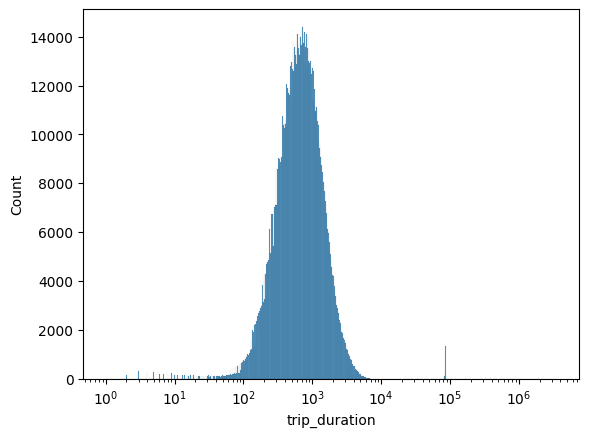

In [12]:
sns.histplot(data=df,x='trip_duration',log_scale=True)

In [13]:
Q1=df['trip_duration'].quantile(0.25)
Q3=df['trip_duration'].quantile(0.75)
IQR=Q3-Q1
upper_bound = Q3 + 3 * IQR
print(upper_bound)

3109.0


In [14]:
df['trip_duration'].mean()

np.float64(959.4922729603659)

In [15]:
df['trip_duration'].median()


np.float64(662.0)

In [16]:
df[df['trip_duration'] < 60]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
72,id1510700,2,2016-02-20 21:58:13,1,-73.958397,40.772629,-73.955132,40.774242,N,57
323,id2954399,1,2016-06-27 11:22:37,1,-74.001030,40.756653,-74.000999,40.756626,N,40
842,id3263580,2,2016-05-21 12:46:46,2,-73.782372,40.648766,-73.782372,40.648746,N,3
853,id2730154,2,2016-03-29 22:39:46,5,-73.982201,40.731812,-73.979950,40.734814,N,58
1107,id0729156,2,2016-06-23 13:36:48,3,-73.827660,40.716175,-73.822113,40.711452,N,2
...,...,...,...,...,...,...,...,...,...,...
1458044,id3200588,2,2016-03-12 01:35:35,1,-74.007378,40.739441,-74.007378,40.739449,N,7
1458085,id1326136,2,2016-05-21 12:07:11,1,-73.978935,40.762463,-73.977654,40.762012,N,17
1458140,id0175875,1,2016-03-22 06:18:10,1,-73.991325,40.744934,-73.989388,40.748024,N,37
1458544,id3958653,1,2016-06-16 15:10:11,1,-73.956459,40.767231,-73.956589,40.767269,N,38


In [17]:
df[df['trip_duration'] > 15000]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
531,id3307903,2,2016-02-20 04:03:06,3,-74.008102,40.741489,-74.009956,40.714611,N,84594
1134,id1091477,2,2016-05-07 18:36:22,1,-73.990242,40.750919,-73.976280,40.750889,N,86149
1865,id3431345,2,2016-06-07 12:58:48,6,-73.954956,40.777649,-73.981033,40.743713,N,86352
3442,id1487069,2,2016-02-13 00:21:49,1,-73.968590,40.799217,-73.979584,40.784714,N,86236
4172,id3674870,2,2016-03-18 11:54:20,1,-73.989090,40.736992,-73.972336,40.751511,N,85197
...,...,...,...,...,...,...,...,...,...,...
1455097,id2798196,2,2016-03-20 03:51:36,2,-73.969299,40.757301,-73.870277,40.709808,N,72504
1456458,id2055880,2,2016-02-08 19:11:31,3,-73.973282,40.760792,-73.988518,40.764210,N,86233
1457207,id1910950,2,2016-06-08 16:29:12,1,-73.958061,40.800869,-73.964119,40.805515,N,85311
1457752,id1215198,2,2016-02-02 11:31:10,6,-73.972069,40.794220,-73.961014,40.806728,N,86314


## Delete invalid trip duration (if a trip less or equal 60s and more or eqaul 2:30 hours)

In [18]:
df=df[(df['trip_duration'] >= 60) & (df['trip_duration'] <= 9000)]

## Pickup_date -> hour, day_of_week,month

In [19]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [20]:
df['hour']=df['pickup_datetime'].dt.hour

In [21]:
df['day_of_week']=df['pickup_datetime'].dt.day_of_week

In [22]:
df['month']=df['pickup_datetime'].dt.month

In [23]:
df

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778,13,4,4
1458640,id1049543,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655,7,6,1
1458641,id2304944,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764,6,4,4
1458642,id2714485,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373,15,1,1


## Target variable plots 

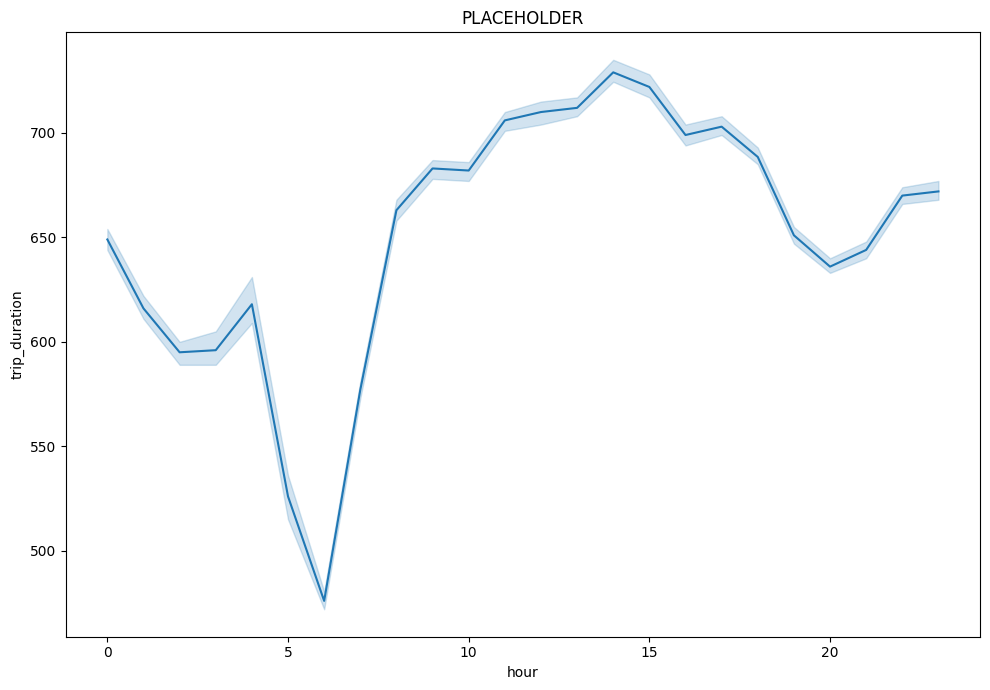

In [24]:
plt.figure(figsize=(10,7))
sns.lineplot(data=df,x='hour',y='trip_duration',estimator='median')
plt.title("PLACEHOLDER")
plt.tight_layout()
plt.show()

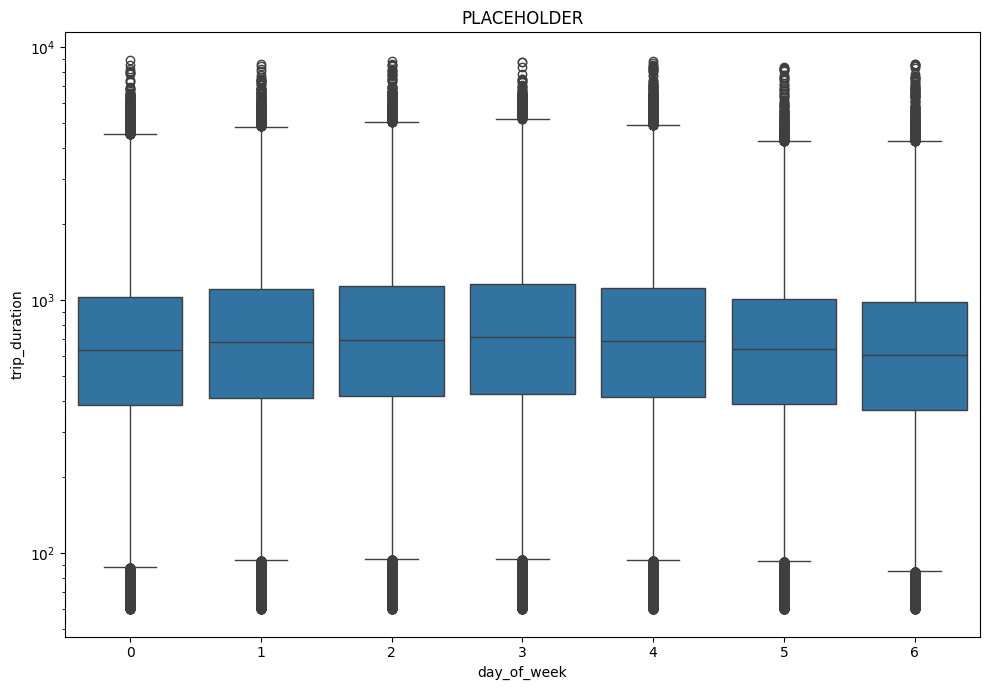

In [25]:
plt.figure(figsize=(10,7))
sns.boxplot(data=df,x='day_of_week',y='trip_duration',log_scale=True)
plt.title("PLACEHOLDER")
plt.tight_layout()
plt.show()

In [26]:
heatmap_data=df.groupby(['day_of_week','hour'])['trip_duration'].median().unstack()

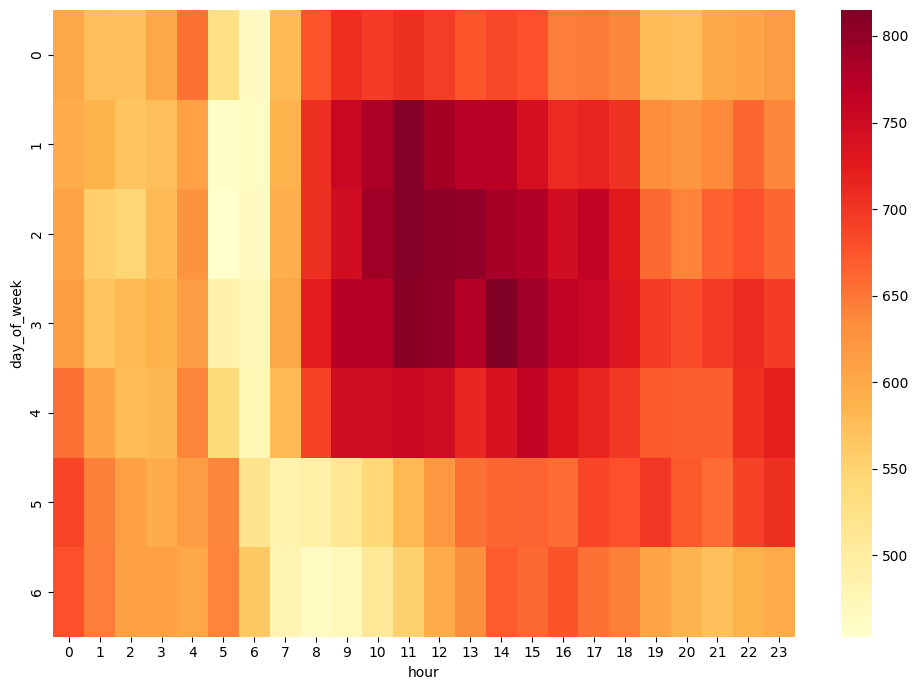

In [27]:
plt.figure(figsize=(10,7))
sns.heatmap(data=heatmap_data,cmap='YlOrRd')
plt.tight_layout()
plt.show()

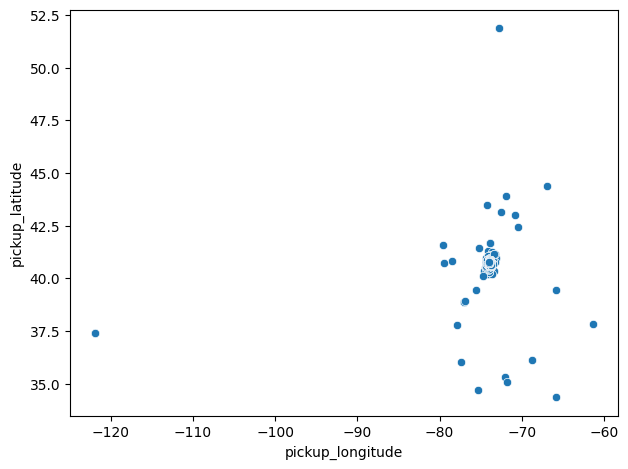

In [28]:
sns.scatterplot(data=df, x='pickup_longitude',y='pickup_latitude')
plt.tight_layout()
plt.show()

In [29]:
limit_df = df.sample(10000)

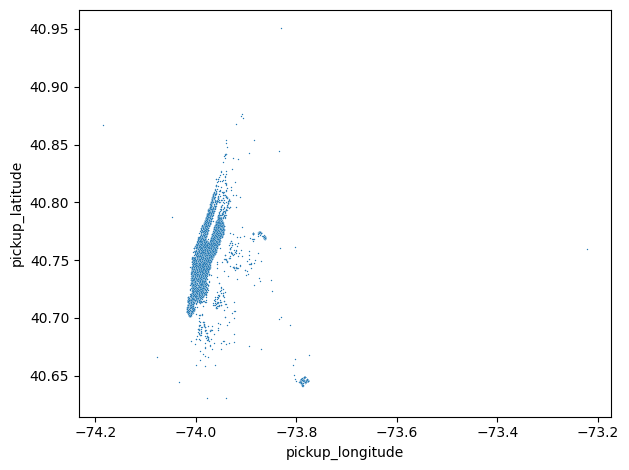

In [30]:
sns.scatterplot(data=limit_df, x='pickup_longitude',y='pickup_latitude',s=1)
plt.tight_layout()
plt.show()

In [31]:
print(f'Pick up latitude mean: {df['pickup_latitude'].mean()}')
print(f'Pick up latitude median: {df['pickup_latitude'].median()}')
print(f'Drop off latitude mean: {df['dropoff_latitude'].mean()}')
print(f'Dropoff latitude median: {df['dropoff_latitude'].median()}')


Pick up latitude mean: 40.75097084978203
Pick up latitude median: 40.75413131713867
Drop off latitude mean: 40.751849959807416
Dropoff latitude median: 40.754558563232415


In [32]:
print(f'Pick up longitude mean: {df['pickup_longitude'].mean()}')
print(f'Pick up longitude median: {df['pickup_longitude'].median()}')
print(f'Drop off longitude mean: {df['dropoff_longitude'].mean()}')
print(f'Dropoff longitude median: {df['dropoff_longitude'].median()}')

Pick up longitude mean: -73.97361827438661
Pick up longitude median: -73.9817657470703
Drop off longitude mean: -73.97354421320041
Dropoff longitude median: -73.97976684570312


In [33]:
df[(df['pickup_longitude']==df['dropoff_longitude']) & (df['pickup_latitude']==df['dropoff_latitude'])]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month
246,id3487442,2,2016-02-29 18:39:12,1,-73.981819,40.768963,-73.981819,40.768963,N,227,18,0,2
291,id0924324,2,2016-05-10 18:07:52,2,-73.959068,40.775661,-73.959068,40.775661,N,1109,18,1,5
407,id1145809,2,2016-05-16 23:15:13,6,-73.808487,40.687336,-73.808487,40.687336,N,947,23,0,5
702,id3499387,1,2016-01-25 19:45:12,1,-73.786720,40.647041,-73.786720,40.647041,N,580,19,0,1
1769,id2892749,1,2016-01-18 15:24:43,5,-73.954666,40.821003,-73.954666,40.821003,Y,254,15,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456399,id0618137,2,2016-02-17 08:57:04,1,-73.978859,40.756721,-73.978859,40.756721,N,1284,8,2,2
1456627,id1048767,2,2016-02-06 22:01:40,1,-73.963554,40.768517,-73.963554,40.768517,N,127,22,5,2
1456989,id2595295,2,2016-03-12 07:37:16,1,-73.984848,40.728222,-73.984848,40.728222,N,566,7,5,3
1457114,id0051314,2,2016-04-09 20:34:21,1,-73.965981,40.770988,-73.965981,40.770988,N,632,20,5,4


In [34]:
df = df[~((df['pickup_longitude'] == df['dropoff_longitude']) & (df['pickup_latitude'] == df['dropoff_latitude']))]

In [35]:
df=df[(df['pickup_longitude'].between(-74.5,-73)) & (df['dropoff_longitude'].between(-74.5,-73)) & (df["dropoff_latitude"].between(40, 41)) & (df["pickup_latitude"].between(40, 41))]

In [40]:
lat1, lng1, lat2, lng2 = map(np.radians, (df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude']))
AVG_EARTH_RADIUS = 6371
lat = lat2 - lat1
lng = lng2 - lng1
d = np.sin(lat * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng * 0.5) ** 2
df['distance_haversine'] = 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))
df['distance_haversine']


0          1.498521
1          1.805507
2          6.385098
3          1.485498
4          1.188588
             ...   
1458639    1.225080
1458640    6.049836
1458641    7.824606
1458642    1.092564
1458643    1.134042
Name: distance_haversine, Length: 1443446, dtype: float64

In [41]:
df['speed_kmh'] = df['distance_haversine'] / (df['trip_duration'] / 3600)

In [42]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [43]:
df['speed_kmh'].describe()

count   1443446.00
mean         14.45
std           7.71
min           0.00
25%           9.20
50%          12.84
75%          17.87
max         583.73
Name: speed_kmh, dtype: float64

In [44]:
df.shape

(1443446, 15)

In [45]:
df = df[(df['speed_kmh'] >= 1) & (df['speed_kmh'] <= 100)]

In [46]:
df.shape

(1439571, 15)

In [47]:
num_feature=df.select_dtypes(include='number')

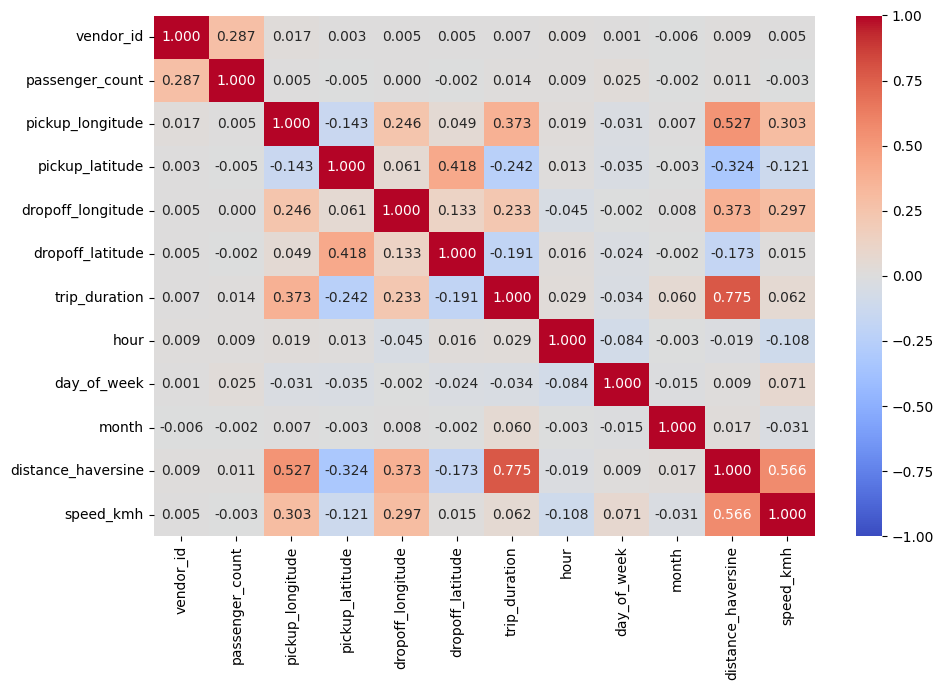

In [48]:
plt.figure(figsize=(10,7))
sns.heatmap(data=num_feature.corr(),cmap='coolwarm',vmin=-1,vmax=1,annot=True,fmt=".3f")
plt.tight_layout()
plt.show()

In [49]:
df = df.drop(columns=['speed_kmh'])

In [50]:
clean_df=df

In [51]:
clean_df.to_csv('data/dataset_clean.csv', index=False)